# Global sensitivity analysis: Mass-action kinetics, single binding 

Nathaniel Linden (UCSD MAE) - March  2023

In [20]:
import sunode
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import sympy as sym
from SALib.sample import sobol as sobol_samp
from SALib.sample import morris as morris_samp
from SALib.analyze import sobol as sobol_analyze
from SALib.analyze import morris as morris_analyze
import corner
import sys
import time
sys.path.insert(0, '../odes')

import ampk_MA_single_mech as model1
%matplotlib inline
plt.style.use('~/.matplotlib/custom.mplstyle')
mpl.rcParams['figure.autolayout'] = True

## Defining bounds for the parameters and unknown initial conditions
Notes:
- Will only vary $K_{\rm d, AMP}$, $K_{\rm d, ADP}$, $K_{\rm d, ATP}$, and estimate forward and reverse rates by fixing the forward rate to 1 and setting the reverse rate accordingly. 
$$
    K_{\rm d} = k_f / k_r
$$
- Assume CamKK2 has a molecular weight of 60-90 kDA (https://www.thermofisher.com/order/catalog/product/PV4206). Thus Vmax varies from 0.286 /s to 0.429 /s. Assume that the total CaMKK2 concentration varies from $1\times 10^{-4}$  to $1\times 10^{-1}$ , thus $k_{\rm phos,CaMKK}$ varies from 28.6 1/s to 4290.0 1/s
- Let kOnCaMKK, kOffCaMKK, kOnLKB1, kOffLKB1, kOnPP, kOffPP, kOnPP1, kOffPP1, kOnAMPK, and kOffAMPK vary from 1e-5 to 1e-1
- Assume total LKB1 concentration varies from $1\times 10^{-5}$ mM to $1\times 10^{-1}$ 
- Assume total CamKK2 concentration varies from $1\times 10^{-4}$ mM to $1\times 10^{-1}$ mM
- Assume total PP concentration varies from $1\times 10^{-4}$ mM to $1\times 10^{-1}$ mM
- Assume total PP1 concentration varies from $1\times 10^{-4}$ mM to $1\times 10^{-1}$ mM
- Assume total AMPKAR concentration varies from $1\times 10^{-4}$ mM to $1\times 10^{-1}$ mM

In [9]:
# define the bounds for the parameters
# we use plus or minus on order of magnitude of any known values and then make resonable assumptions for unknowns
nominal_vals = [
   2.5e-3, # KdAMP
   1.5e-3, # KdADP
   1.7e-3, # KdATP
   90.467, # kOnCaMKK = (koff+kphos/Km)
   1.0, # kOffCaMKK = 1
   0.357, # kPhosCaMKK
   0.742, # kOnLKB1
   1.0, # kOffLKB1
   3.92e-2, # kPhosLKB1
   16.56, # kOnPP
   1.0, # kOffPP
   1.1e-1, # kDephosPP
   1569.59, # kOnAMPK
   1.0, # kOffAMPK
   6.33, # kPhosAMPK
   16.56, # kOnPP1
   1.0, # kOffPP1
   1.1e-1, # kDephosPP1
   1e-3, # AMPKAR
]

# vary parameters by 50% and 20%
bounds_50 = [[0.5*param, 1.5*param] for param in nominal_vals]
bounds_90 = [[0.1*param, 1.9*param] for param in nominal_vals]

param_names = ['KdAMP', 'KdADP', 'KdATP', 'kOnCaMKK','kOffCaMKK', 'kPhosCaMKK', 
               'kOnLKB1','kOffLKB1','kPhosLKB1','kOnPP','kOffPP','kDephosPP', 
               'kOnAMPK','kOffAMPK','kPhosAMPK', 'kOnPP1','kOffPP1', 'kDephosPP1', 'AMPKAR']
state_names = ['AMP', 'ADP', 'ATP', 'AMPK', 'pAMPK', 'AMP_AMPK', 'ADP_AMPK', 'ATP_AMPK', 'AMP_pAMPK', 'ADP_pAMPK', 'ATP_pAMPK', 'CaMKK', 'CaMKK_AMPK', 'CaMKK_AMP_AMPK', 'CaMKK_ADP_AMPK', 'CaMKK_ATP_AMPK', 'LKB1', 'LKB1_AMP_AMPK', 'LKB1_ADP_AMPK', 'PP', 'PP_pAMPK', 'PP_ATP_pAMPK', 'AMPKAR', 'pAMPKAR', 'AMPKAR_AMP_pAMPK', 'PP1', 'PP1_pAMPKAR']

# dictionary of the problem for SALib
problem_50 = {'num_vars':19, 'names':param_names, 'bounds': bounds_50,}
problem_90 = {'num_vars':19, 'names':param_names, 'bounds': bounds_90,}

seed = np.random.seed(seed=2048)

We will start by defining a function that takes a matrix of paramss and evaluates the model accordingly

In [13]:
# initialize the initial condition dictionary
# Initial conditions
def set_init_conds(problem_ode, state_names):
    y0 = np.zeros((), dtype=problem_ode.state_dtype)
    to_set = ['AMP', 'ADP', 'ATP', 'AMPK', 'CaMKK', 'LKB1', 'PP', 'PP1', 'AMPKAR']
    not_set = list(set(state_names) - set(to_set))
    #free adenine nucleotides
    y0['AMP'] = 2e-5   # 'AMP' mM
    y0['ADP'] = 1.3e-1 # 'ADP mM
    y0['ATP'] = 8.2   # 'ATP mM
    y0['AMPK'] = 0.6   # 'AMPK mM
    y0['CaMKK'] = 1.0   # 'CaMKK_AMPK mM
    y0['LKB1'] = 1.0   # 'CaMKK_AMPK mM
    y0['PP'] = 1.0   # 'CaMKK_AMPK mM
    y0['AMPKAR'] = 0.1   # 'AMPKAR mM
    y0['PP1'] = 1.0   # 'CaMKK_AMPK mM

    return y0

def single_model_eval(params, problem, solver, y0, tvals, state_names):

    # update relevant initial conditions 
    y0['AMPKAR'] = params[18]

    # NORMAL GLYCOLYSIS
    # set the parameters
    solver.set_params_dict({
        'kOnAMP': 1.0, # 1/(mM s) 
        'kOffAMP': params[0], # kr = 1/Kd
        'kOnADP': 1.0 ,
        'kOffADP': params[1], # kr = 1/Kd
        'kOnATP': 1.0, 
        'kOffATP': params[2], # kr = 1/Kd
        'kOnCaMKK': params[3],
        'kOffCaMKK': params[4], 
        'kPhosCaMKK': params[5], 
        'kOnLKB1': params[6], 
        'kOffLKB1': params[7],
        'kPhosLKB1': params[8], 
        'kOnPP': params[9], 
        'kOffPP': params[10],
        'kDephosPP': params[11],
        'kOnAMPK': params[12],
        'kOffAMPK': params[13],
        'kPhosAMPK': params[14],
        'kOnPP1': params[15],
        'kOffPP1': params[16],
        'kDephosPP1': params[17],
        'kGly': 1300.0,
        'kHydro':1.4e-3,
        'kForAK':40.44,
        'kRevAK':1.1e-3,
        'VmaxOxPhos':0.5,
        'Kadp': 5.8e-2,
        'n': 2.568,
    })

    yout = solver.make_output_buffers(tvals)
    solver.solve(t0=0, tvals=tvals, y0=y0, y_out=yout)
    
    y0_new = np.zeros((), dtype=problem_ode.state_dtype)
    for state in state_names:
        y0_new[state] = yout.view(problem_ode.state_dtype)[state][-1]

    # PERTUBED GLYCOLYSIS
    # set the parameters
    solver.set_params_dict({
        'kOnAMP': 1.0, # 1/(mM s) 
        'kOffAMP': params[0], # kr = 1/Kd
        'kOnADP': 1.0 ,
        'kOffADP': params[1], # kr = 1/Kd
        'kOnATP': 1.0, 
        'kOffATP': params[2], # kr = 1/Kd
        'kOnCaMKK': params[3],
        'kOffCaMKK': params[4], 
        'kPhosCaMKK': params[5], 
        'kOnLKB1': params[6], 
        'kOffLKB1': params[7],
        'kPhosLKB1': params[8], 
        'kOnPP': params[9], 
        'kOffPP': params[10],
        'kDephosPP': params[11],
        'kOnAMPK': params[12],
        'kOffAMPK': params[13],
        'kPhosAMPK': params[14],
        'kOnPP1': params[15],
        'kOffPP1': params[16],
        'kDephosPP1': params[17],
        'kGly': 4.5, # LOWER RATE!
        'kHydro':1.4e-3,
        'kForAK':40.44,
        'kRevAK':1.1e-3,
        'VmaxOxPhos':0.5,
        'Kadp': 5.8e-2,
        'n': 2.568,
    })

    # test
    yout1 = solver.make_output_buffers(tvals)
    solver.solve(t0=0, tvals=tvals, y0=y0_new, y_out=yout1)

    # now compute the output QoIs
    # pAMPKAR/AMPKAR steady-state before perturb
    pAMPKAR_AMPKAR_ss = yout.view(problem.state_dtype)['pAMPKAR'][-1] / yout.view(problem.state_dtype)['AMPKAR'][-1]

    # change after glycolysis perturbation
    pAMPKAR_AMPKAR_final_ss = yout1.view(problem.state_dtype)['pAMPKAR'][-1] / yout1.view(problem.state_dtype)['AMPKAR'][-1]
    pAMPKAR_AMPKAR_delta = pAMPKAR_AMPKAR_final_ss - pAMPKAR_AMPKAR_ss

    return np.array([pAMPKAR_AMPKAR_ss, pAMPKAR_AMPKAR_delta]), yout, yout1

In [14]:
# SET UP problem and SOLVER
# load the necessary dictionaries
params = model1.ampk_MA_single_mech_get_params()
states = model1.ampk_MA_single_mech_get_states()
nparams = len(params)
nstates = len(states)

# create sunode problem
problem_ode = sunode.SympyProblem(
    params=params,
    states=states,
    rhs_sympy=model1.ampk_MA_single_mech_RHS,
    # specify variables to take gradients wrt
    derivative_params=(),
)

# solver
solver = sunode.solver.Solver(problem_ode, solver='BDF')
lib = sunode._cvodes.lib
lib.CVodeSetMaxNumSteps(solver._ode, 5000) # increase max steps

y0 = set_init_conds(problem_ode, state_names)

 # evaluate the solution at these times
tvals = np.linspace(0, 3000, 1000)


In [22]:
# generate samples using the Saltelli and Morris sampling methods
# plot resulting solutions to see if the ranges make sense
nsamps = 16
param_vals_sobol = sobol_samp.sample(problem_90, nsamps, calc_second_order=True, seed=seed)
param_vals_morris = morris_samp.sample(problem_90, nsamps, seed=seed)

sols_sobol = [single_model_eval(param, problem_ode, 
                      solver, set_init_conds(problem_ode, state_names), 
                      tvals, state_names) for param in param_vals_sobol]

sols_morris = [single_model_eval(param, problem_ode,
                        solver, set_init_conds(problem_ode, state_names),
                        tvals, state_names) for param in param_vals_morris]

/Users/natel/miniconda3/envs/pymc_env/lib/python3.10/site-packages/scipy/stats/_qmc.py:763: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


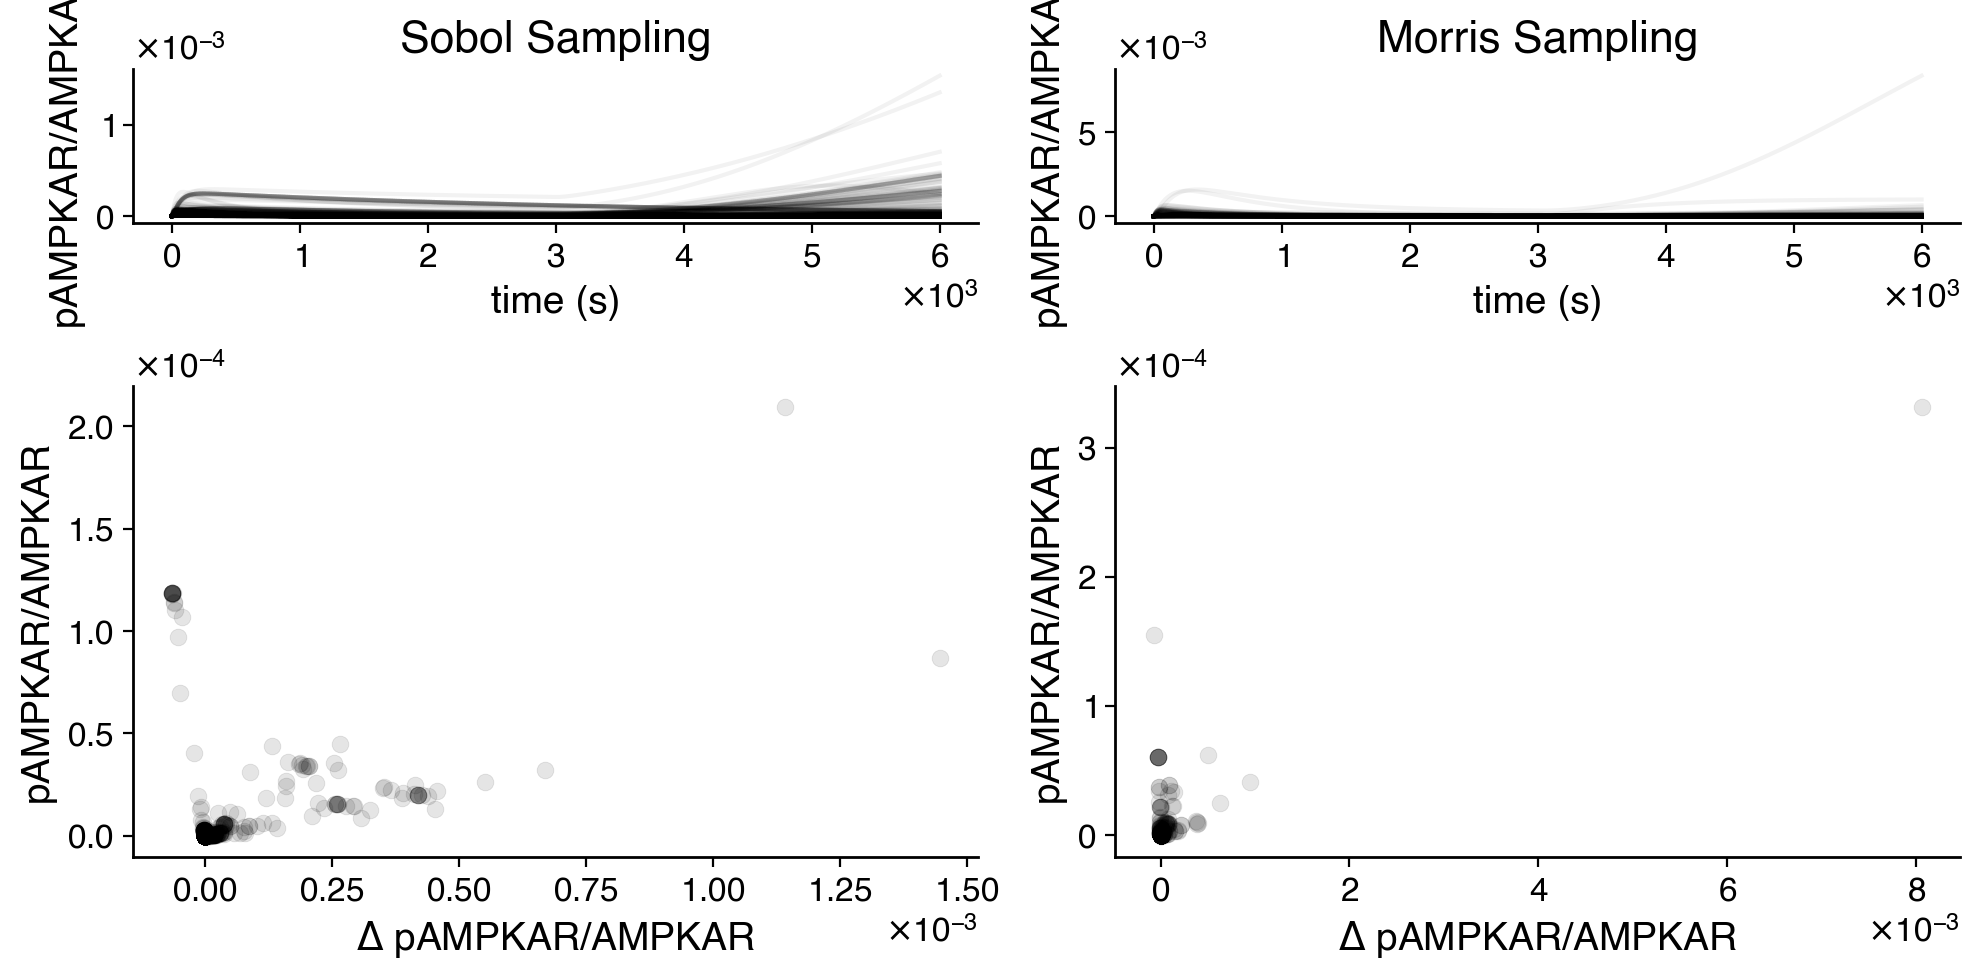

In [16]:
# plot the solutions
# fig, ax = plt.subplots(3, 2, figsize=(10,10))
# f, (a0, a1) = plt.subplots(1, 2, height_ratios=[3, 1])
fig, ax = plt.subplot_mosaic([['traj A', 'traj B'],
     ['scat A', 'scat B'],
     ['scat A', 'scat B']],figsize=(10,5))
for sol in sols_sobol:
    traj = np.vstack((sol[1].view(problem_ode.state_dtype)['pAMPKAR']/sol[1].view(problem_ode.state_dtype)['AMPKAR'],
                      sol[2].view(problem_ode.state_dtype)['pAMPKAR']/sol[2].view(problem_ode.state_dtype)['AMPKAR']))
    ax['traj A'].plot(np.hstack((tvals, tvals[-1]+tvals)), traj, color='k', alpha=0.05)
    ax['scat A'].scatter(sol[0][1], sol[0][0], color='k', alpha=0.1)
    

for sol in sols_morris:
    traj = np.vstack((sol[1].view(problem_ode.state_dtype)['pAMPKAR']/sol[1].view(problem_ode.state_dtype)['AMPKAR'],
                      sol[2].view(problem_ode.state_dtype)['pAMPKAR']/sol[2].view(problem_ode.state_dtype)['AMPKAR']))
    ax['traj B'].plot(np.hstack((tvals, tvals[-1]+tvals)), traj, color='k', alpha=0.05)
    ax['scat B'].scatter(sol[0][1], sol[0][0], color='k', alpha=0.1)


# plot formatting
ax['traj A'].set_xlabel('time (s)')
ax['traj A'].set_ylabel('pAMPKAR/AMPKAR')
ax['traj A'].set_title('Sobol Sampling')

ax['scat A'].set_xlabel('$\Delta$ pAMPKAR/AMPKAR')
ax['scat A'].set_ylabel('pAMPKAR/AMPKAR')

ax['traj B'].set_xlabel('time (s)')
ax['traj B'].set_ylabel('pAMPKAR/AMPKAR')
ax['traj B'].set_title('Morris Sampling')

ax['scat B'].set_xlabel('$\Delta$ pAMPKAR/AMPKAR')
ax['scat B'].set_ylabel('pAMPKAR/AMPKAR')
fig.savefig('./MA_single_mech/bounds_test.pdf')

In [17]:
# generate samples using the Saltelli and Morris sampling methods
param_vals_sobol = sobol_samp.sample(problem_90, 4096, calc_second_order=True, seed=seed)
param_vals_morris = morris_samp.sample(problem_90, 4096, seed=seed)
# now run the model with the Sobol set of samples
tstart = time.time()
sobol_outputs = [single_model_eval(p_set, problem_ode, 
                      solver, set_init_conds(problem_ode, state_names), 
                      tvals, state_names)[0] for p_set in param_vals_sobol]
tend = time.time()
print('Simulating the {} Sobol parameter sets took {} seconds'.format(param_vals_sobol.shape[0], tend-tstart))

np.save('./MA_single_mech/20230327_GSA_MA_single_mech_sobol_samples', np.array(sobol_outputs))

Simulating the 163840 Sobol parameter sets took 3633.526389837265 seconds


In [18]:
# And the Morris set of samples
tstart = time.time()
morris_outputs = [single_model_eval(p_set, problem_ode, 
                      solver, set_init_conds(problem_ode, state_names), 
                      tvals, state_names)[0] for p_set in param_vals_morris]
tend = time.time()
print('Simulating the {} Morris parameter sets took {} seconds'.format(param_vals_morris.shape[0], tend-tstart))

np.save('./MA_single_mech/20230327_GSA_MA_single_mech_morris_samples', np.array(morris_outputs))

Simulating the 81920 Morris parameter sets took 944.6145560741425 seconds


In [19]:
# convert lists to numpy arrays and remove extra dimension
m_outputs_np = np.squeeze(np.array(morris_outputs))
s_outputs_np = np.squeeze(np.array(sobol_outputs))

# compute sensitivity indices
Si_morris_ss = morris_analyze.analyze(problem_90, param_vals_morris, m_outputs_np[:,0])
Si_morris_delta = morris_analyze.analyze(problem_90, param_vals_morris, m_outputs_np[:,1])
Si_sobol_ss = sobol_analyze.analyze(problem_90, s_outputs_np[:,0], calc_second_order=True)
Si_sobol_delta = sobol_analyze.analyze(problem_90, s_outputs_np[:,1], calc_second_order=True)

In [20]:
# sort sobol indices by ST
dtype = [('name', 'U10'), ('S1', float), ('S1_conf', float), ('ST', float), ('ST_conf', float)]

Si_sobol_ss_sorted = np.array([(name, S1, S1_conf, ST, ST_conf) for 
                               name, S1, S1_conf, ST, ST_conf in zip(param_names, Si_sobol_ss['S1'], Si_sobol_ss['S1_conf'], 
                                                                     Si_sobol_ss['ST'], Si_sobol_ss['ST'])], dtype=dtype)
Si_sobol_ss_sorted = np.sort(Si_sobol_ss_sorted, order='S1')[::-1]

Si_sobol_delta_sorted = np.array([(name, S1, S1_conf, ST, ST_conf) for 
                               name, S1, S1_conf, ST, ST_conf in zip(param_names, Si_sobol_delta['S1'], Si_sobol_delta['S1_conf'], 
                                                                     Si_sobol_delta['ST'], Si_sobol_delta['ST'])], dtype=dtype)
Si_sobol_delta_sorted = np.sort(Si_sobol_delta_sorted, order='S1')[::-1]

# sort Morris indices by mu_star
dtype = [('name', 'S10'), ('mu_star', float), ('sigma', float), ('mu', float), ('mu_star_conf', float)]

Si_morris_ss_sorted = np.array([(name, mu_star, sigma, mu, mu_star_conf) for 
                               name, mu_star, sigma, mu, mu_star_conf in zip(param_names, Si_morris_ss['mu_star'], Si_morris_ss['sigma'], 
                                                                     Si_morris_ss['mu'], Si_morris_ss['mu_star_conf'])], dtype=dtype)
Si_morris_ss_sorted = np.sort(Si_morris_ss_sorted, order='mu_star')

Si_morris_delta_sorted = np.array([(name, mu_star, sigma, mu, mu_star_conf) for 
                               name, mu_star, sigma, mu, mu_star_conf in zip(param_names, Si_morris_delta['mu_star'], Si_morris_delta['sigma'], 
                                                                     Si_morris_delta['mu'], Si_morris_delta['mu_star_conf'])], dtype=dtype)
Si_morris_delta_sorted = np.sort(Si_morris_delta_sorted, order='mu_star')

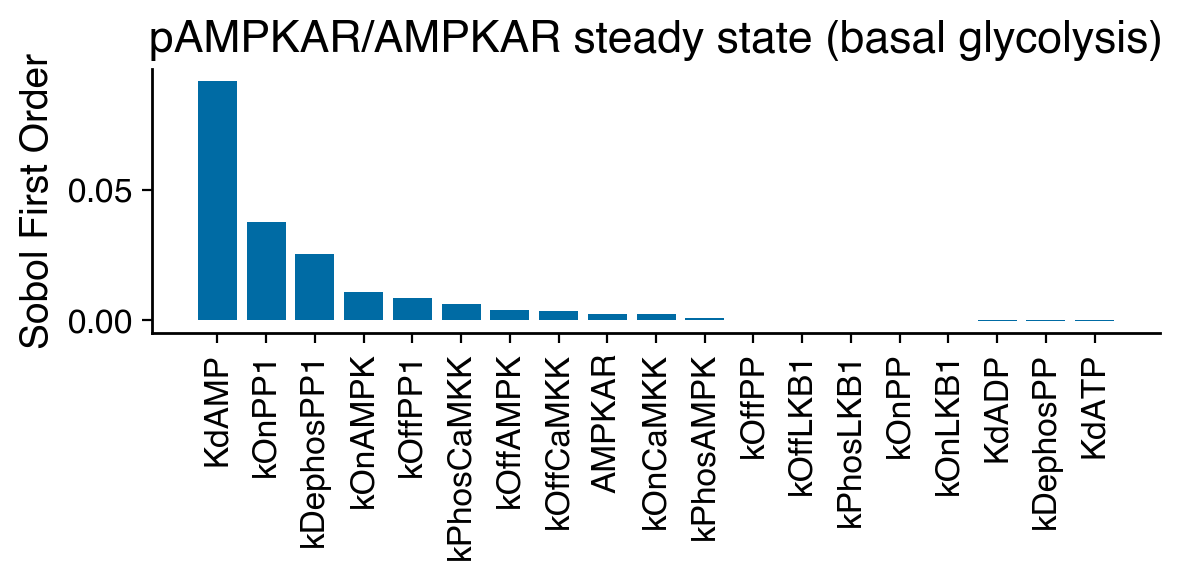

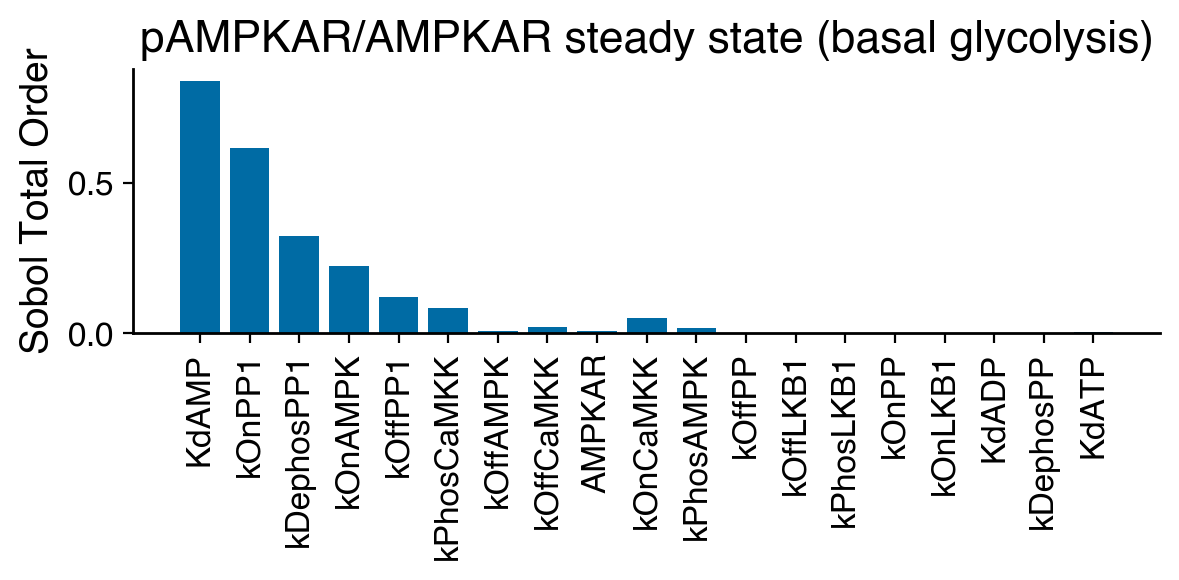

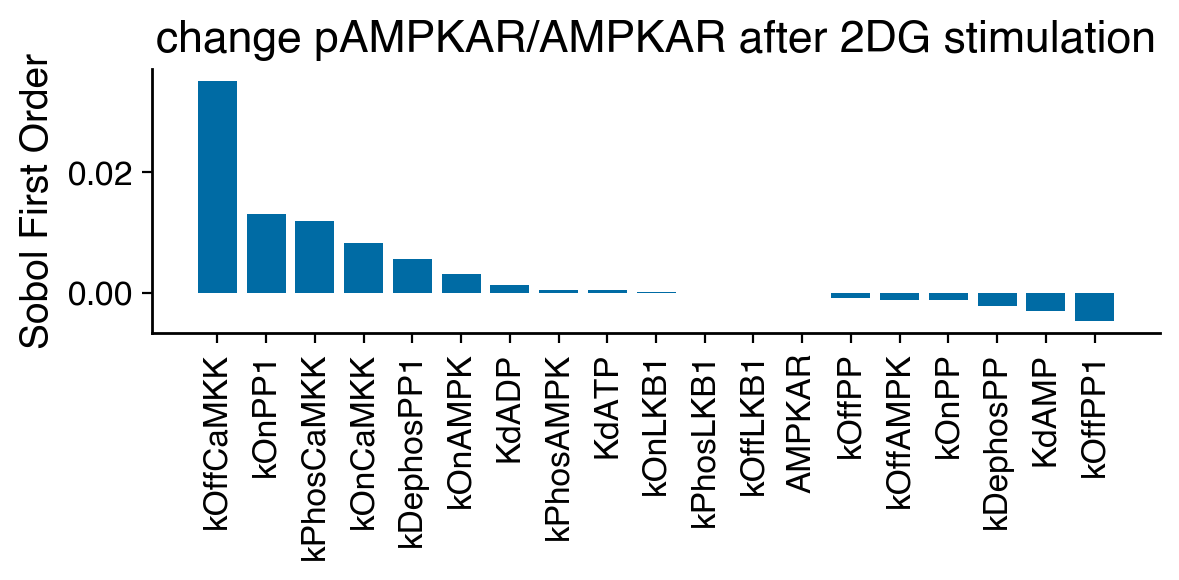

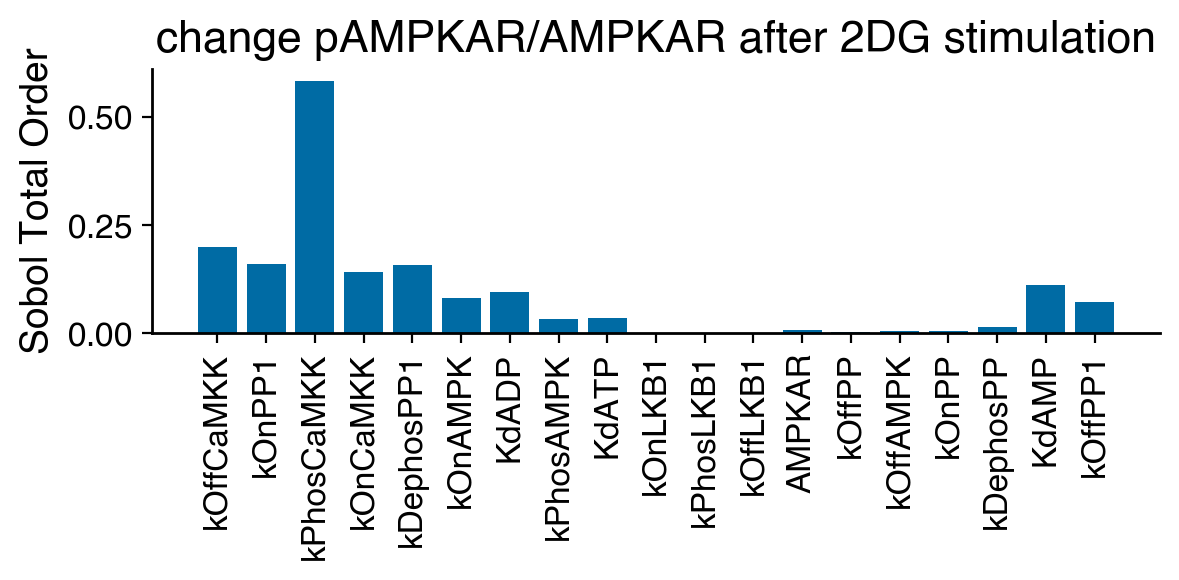

In [21]:
fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,19), Si_sobol_ss_sorted['S1'],
        # yerr=Si_sobol_ss_sorted['S1_conf'],
        log=False)
plt.xticks(np.arange(0,19), Si_sobol_ss_sorted['name'], rotation='vertical')
plt.ylabel('Sobol First Order')
plt.title('pAMPKAR/AMPKAR steady state (basal glycolysis)')
fig.savefig('./MA_single_mech/GSA_MA_single_mech_S1_ss.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,19), Si_sobol_ss_sorted['ST'],
        # yerr=Si_sobol_ss_sorted['ST_conf'],
        log=False)
plt.xticks(np.arange(0,19), Si_sobol_ss_sorted['name'], rotation='vertical')
plt.ylabel('Sobol Total Order')
plt.title('pAMPKAR/AMPKAR steady state (basal glycolysis)')
fig.savefig('./MA_single_mech/GSA_MA_single_mech_ST_ss.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,19), Si_sobol_delta_sorted['S1'],
        # yerr=Si_sobol_delta_sorted['S1_conf'],
        log=False)
plt.xticks(np.arange(0,19), Si_sobol_delta_sorted['name'], rotation='vertical')
plt.ylabel('Sobol First Order')
plt.title('change pAMPKAR/AMPKAR after 2DG stimulation')
fig.savefig('./MA_single_mech/GSA_MA_single_mech_S1_delta.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,19), Si_sobol_delta_sorted['ST'],
        # yerr=Si_sobol_delta_sorted['ST_conf'],
        log=False)
plt.xticks(np.arange(0,19), Si_sobol_delta_sorted['name'], rotation='vertical')
plt.ylabel('Sobol Total Order')
plt.title('change pAMPKAR/AMPKAR after 2DG stimulation')
fig.savefig('./MA_single_mech/GSA_MA_single_mech_ST_delta.pdf')
plt.show()

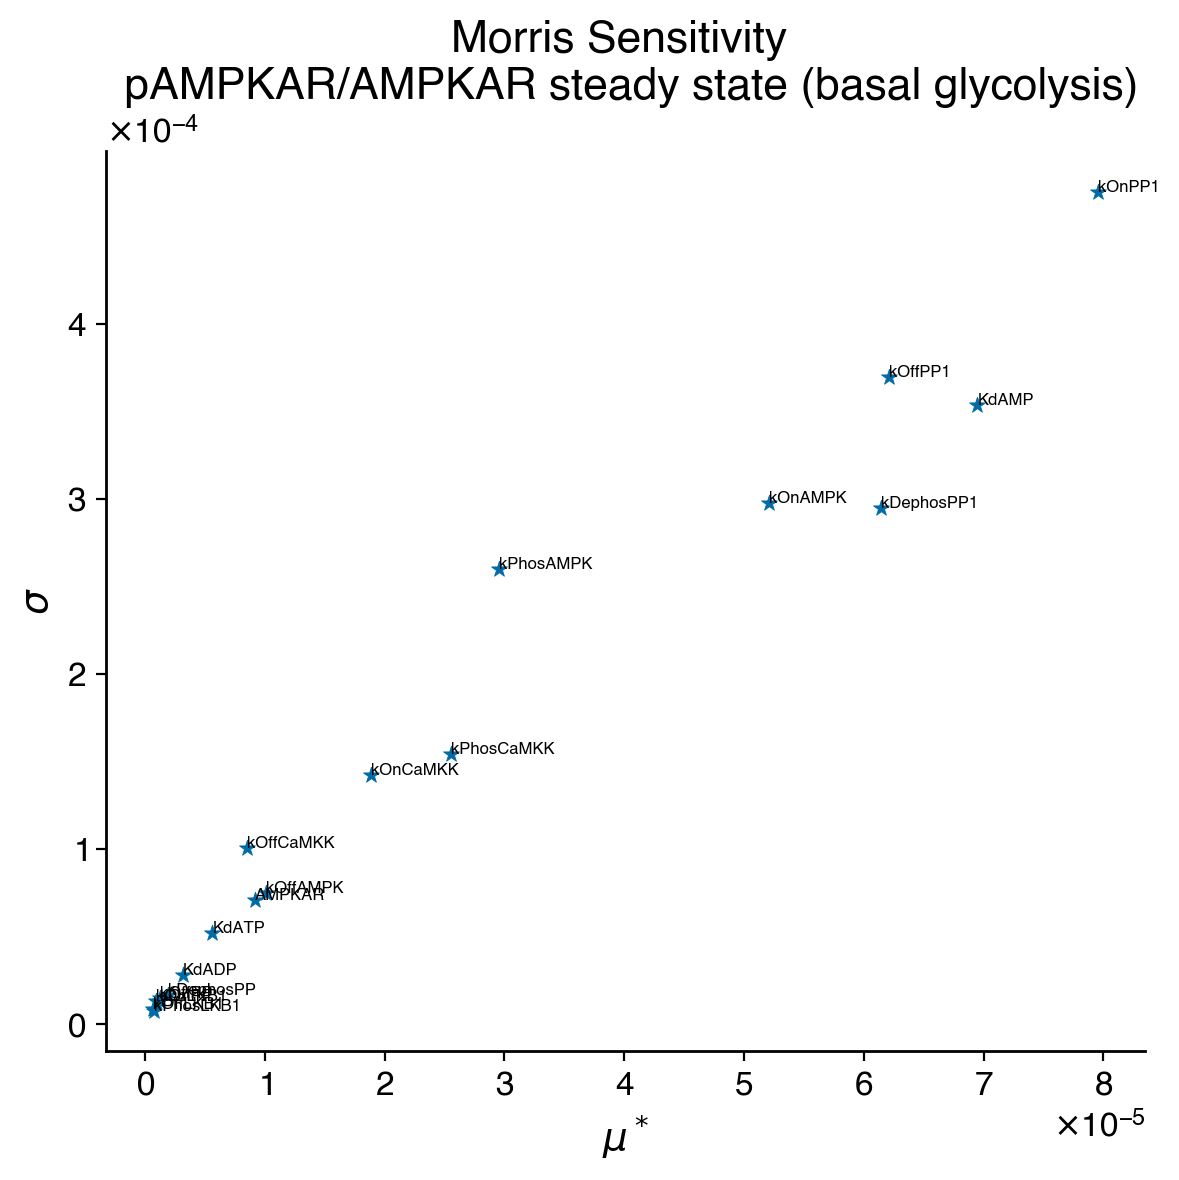

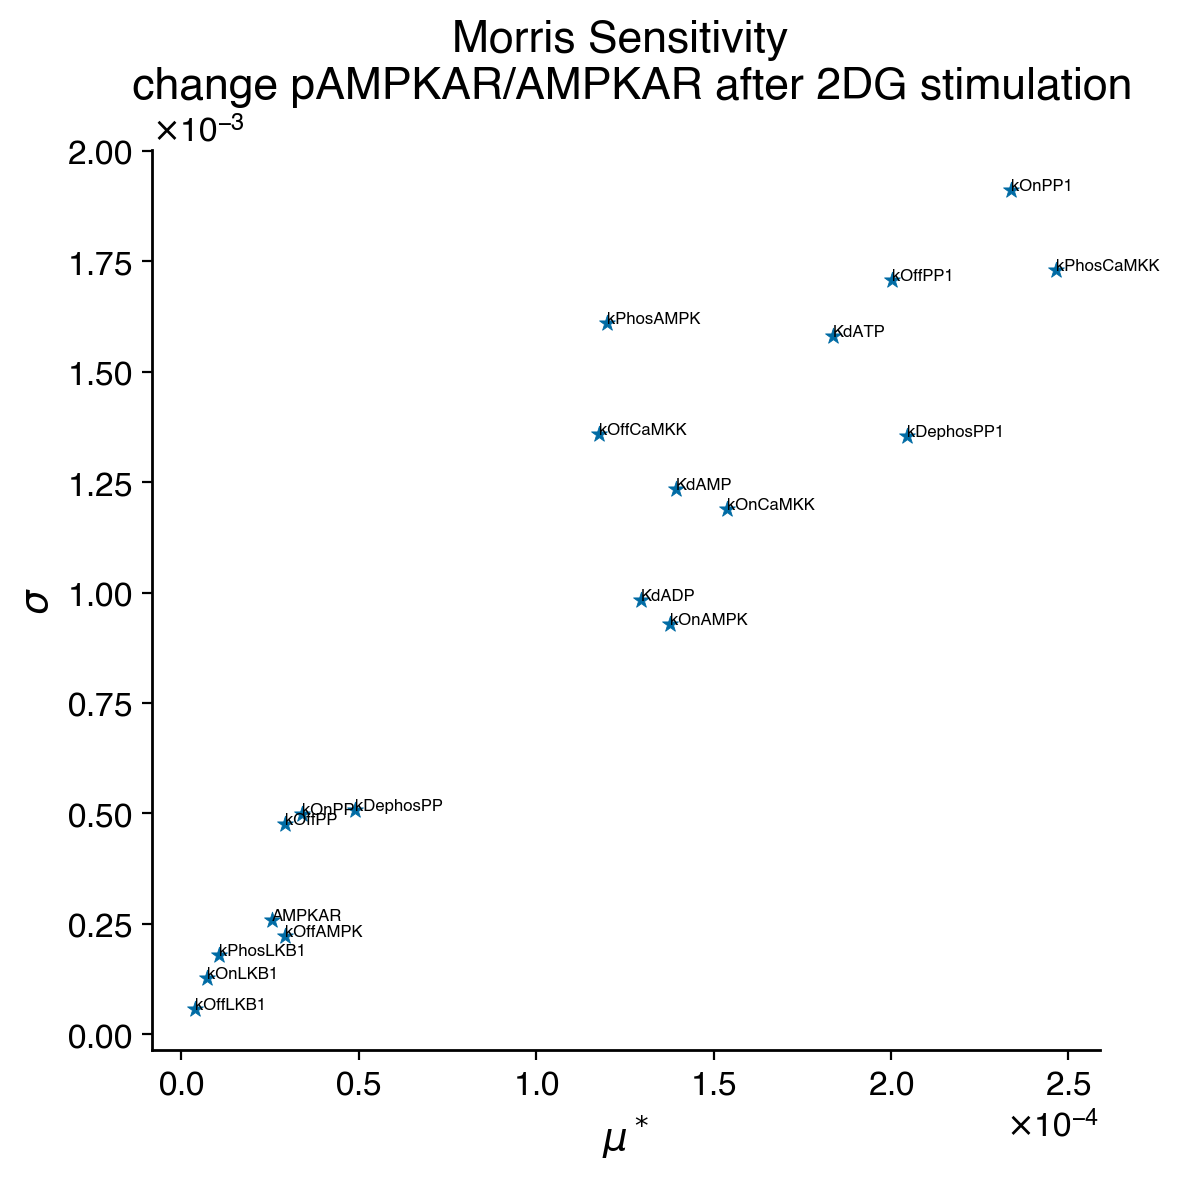

In [22]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(Si_morris_ss_sorted['mu_star'], Si_morris_ss_sorted['sigma'], marker='*',
           )
# ax.plot([0.05, 0.05], [0, 10], 'r', linewidth=1)
# ax.set_xscale('log')
# ax.set_yscale('log')

for i, name_mu_star in enumerate(zip(Si_morris_ss['names'], Si_morris_ss['mu_star'])):
    if name_mu_star[1] >= 5.0e-10:
        ax.annotate(name_mu_star[0], (name_mu_star[1], Si_morris_ss['sigma'][i]), fontsize=6)

ax.set_ylabel('$\sigma$')
ax.set_xlabel('$\mu^*$')
ax.set_title('Morris Sensitivity \n pAMPKAR/AMPKAR steady state (basal glycolysis)')
fig.savefig('./MA_single_mech/GSA_MA_single_mech_morris_ss.pdf')

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(Si_morris_delta_sorted['mu_star'], Si_morris_delta_sorted['sigma'], marker='*',
           )
# ax.plot([0.05, 0.05], [0, 1e-10], 'r', linewidth=1)
# ax.set_xscale('log')
# ax.set_yscale('log')

for i, name_mu_star in enumerate(zip(Si_morris_delta['names'], Si_morris_delta['mu_star'])):
    if name_mu_star[1] >= 5.0e-9:
        ax.annotate(name_mu_star[0], (name_mu_star[1], Si_morris_delta['sigma'][i]), fontsize=6)

ax.set_ylabel('$\sigma$')
ax.set_xlabel('$\mu^*$')
ax.set_title('Morris Sensitivity \n change pAMPKAR/AMPKAR after 2DG stimulation')
fig.savefig('./MA_single_mech/GSA_MA_single_mech_morris_delta.pdf')


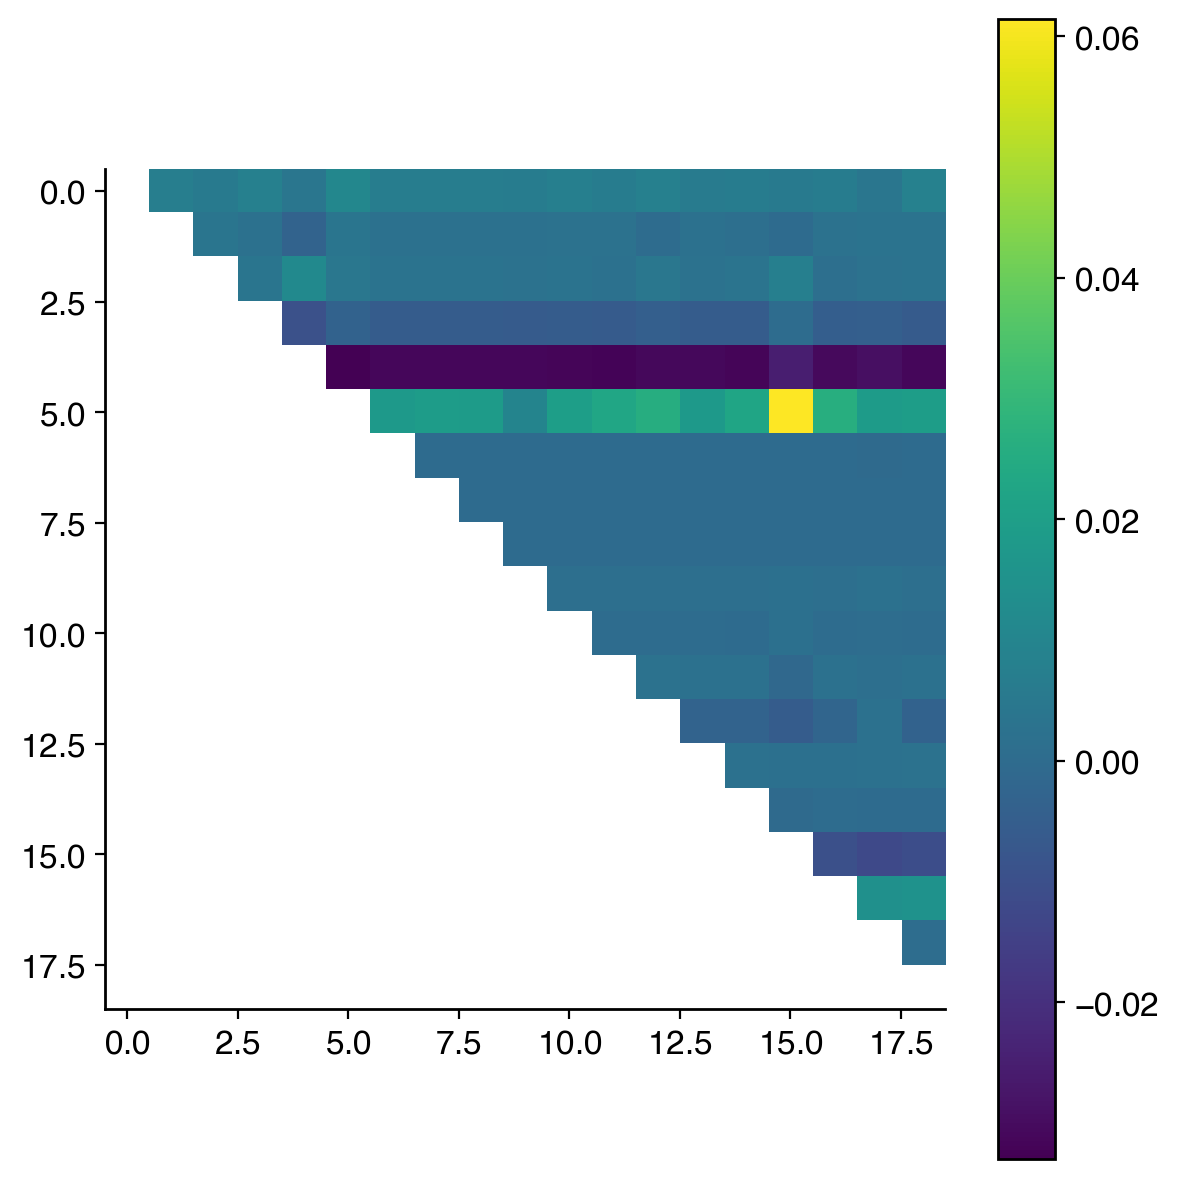

In [25]:
fig, ax = plt.subplots(figsize=(6,6))
plt.imshow(Si_sobol_delta['S2'], cmap='viridis')
plt.colorbar()